# Run the bottle object detector over local stitched Johnnie Walker clips

This is the local-files equivalent of `02_detect_s3_clips.ipynb`.
It processes the already-created **10 seconds before / 5 seconds after** event clips,
runs every frame on CUDA, and leaves the source videos unchanged.

Outputs include resumable frame/clip CSVs, annotated videos grouped by result,
peak annotated frames for fallen detections, temporal fall classification, and
an L14 CSV with the two incident-result columns.

## 1. Imports and configuration

In [3]:
import json
import re
import sys
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path

import cv2
import pandas as pd
import torch

working_directory = Path.cwd().resolve()
repository_candidates = []
for candidate in [working_directory, *working_directory.parents]:
    repository_candidates.extend([candidate, candidate / "24H_Insights"])
REPO_ROOT = next(
    (candidate for candidate in repository_candidates if (candidate / "VideoModule").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not find the project root containing VideoModule")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from VideoModule.detection import (
    get_detection_summary,
    load_yolo_model,
    run_yolo_detection,
    visualize_yolo_detections,
)

PIPELINE_ROOT = REPO_ROOT / "stoppage_detection_and_classification"
OBJECT_DETECTION_DIR = PIPELINE_ROOT / "object_detection"
PLC_EVENTS_DIR = PIPELINE_ROOT / "plc_stoppage_events"
PLC_EVENTS_OUTPUT_DIR = PLC_EVENTS_DIR / "output" / "01_prepare_events"
PLC_L14_EVENTS_DIR = PLC_EVENTS_DIR / "data" / "plc_l14_events"

@dataclass(frozen=True)
class Config:
    input_dir: Path = (
        PLC_EVENTS_DIR
        / "output"
        / "02_deduplicate_and_generate_event_clips"
        / "stitched_event_clips"
    )
    checkpoint: Path = OBJECT_DETECTION_DIR / "models" / "yolov8n_paired_best.pt"
    output_dir: Path = OBJECT_DETECTION_DIR / "output" / "03_detect_stitched_clips"
    events_csv: Path = PLC_EVENTS_OUTPUT_DIR / "johnnie_walker_black_label_events_2026-07-23.csv"
    source_events_xls: Path = PLC_L14_EVENTS_DIR / "L14 Shrinkwrap - Unhealth Events FYTD.xls"
    event_timezone: str = "Europe/London"
    event_window_before_seconds: float = 10.0
    event_window_after_seconds: float = 5.0
    sample_fps: float | None = None
    confidence_threshold: float = 0.25
    fallen_detection_threshold: float = 0.55
    upright_temporal_threshold: float = 0.40
    iou_threshold: float = 0.45
    rotate_from_timestamp_utc: datetime = datetime(2026, 6, 21)
    minimum_fallen_frames: int = 3
    save_annotated_videos: bool = True
    run_batch: bool = True
    max_clips: int | None = None
    reprocess_successful: bool = False

CFG = Config()
for directory in (
    CFG.output_dir,
    CFG.output_dir / "annotated_videos",
    CFG.output_dir / "annotated_peak_frames" / "fallen_detected",
):
    directory.mkdir(parents=True, exist_ok=True)

if not CFG.input_dir.is_dir():
    raise FileNotFoundError(f"Stitched clip directory not found: {CFG.input_dir}")
if not CFG.checkpoint.is_file():
    raise FileNotFoundError(f"Detector checkpoint not found: {CFG.checkpoint}")
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required; select the 24H Object Detection (CUDA) kernel")

print(f"Input:      {CFG.input_dir}")
print(f"Checkpoint: {CFG.checkpoint}")
print(f"Output:     {CFG.output_dir}")
print(f"GPU:        {torch.cuda.get_device_name(0)}")
print(f"Sampling:   {'every frame' if CFG.sample_fps is None else f'{CFG.sample_fps:g} FPS'}")
print(f"Window:     {CFG.event_window_before_seconds:g}s before / {CFG.event_window_after_seconds:g}s after")
print(f"Fallen threshold: {CFG.fallen_detection_threshold:.2f}")
print(f"Run batch:  {CFG.run_batch}")

Input:      C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\plc_stoppage_events\output\02_deduplicate_and_generate_event_clips\stitched_event_clips
Checkpoint: C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\data\object_detection_poc_runs_paired\yolo_n\weights\best.pt
Output:     C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\output\03_detect_stitched_clips
GPU:        NVIDIA GeForce RTX 5080 Laptop GPU
Sampling:   every frame
Window:     10s before / 5s after
Fallen threshold: 0.55
Run batch:  True


## 2. Load the detector on CUDA

In [4]:
detector = load_yolo_model(CFG.checkpoint, device="cuda:0")
print(f"Classes: {detector.get_class_names()}")
print(f"CUDA device: {detector.device}")

2026-07-27 21:33:39,512 - INFO - Initialized YOLODetector with model size: yolov8m
2026-07-27 21:33:39,512 - INFO -   Device: cuda
2026-07-27 21:33:39,513 - INFO - Loading YOLO checkpoint: C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\data\object_detection_poc_runs_paired\yolo_n\weights\best.pt
2026-07-27 21:33:39,529 - INFO - ✓ Loaded checkpoint with 2 classes
2026-07-27 21:33:39,530 - INFO -   Classes: ['fallen_bottle', 'upright_bottles']


Classes: ['fallen_bottle', 'upright_bottles']
CUDA device: cuda:0


## 3. Build the local stitched-clip queue

In [5]:
VIDEO_EXTENSIONS = {".mp4", ".ts", ".avi", ".mov", ".mkv", ".m4v"}
STITCHED_NAME_PATTERN = re.compile(
    r"^(stoppage_\d{6})__(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}_\d+)__10s_before_5s_after$"
)

events = pd.read_csv(CFG.events_csv).reset_index(drop=True)
if "Event Time" not in events.columns:
    raise ValueError("The event CSV does not contain an 'Event Time' column")
events.insert(0, "event_id", [f"stoppage_{index + 1:06d}" for index in range(len(events))])
events["event_time_local"] = pd.to_datetime(events["Event Time"], errors="raise").dt.tz_localize(
    CFG.event_timezone, ambiguous="raise", nonexistent="raise"
)
events["event_time_utc"] = events["event_time_local"].dt.tz_convert("UTC").dt.tz_localize(None)

queue_rows = []
ignored = []
for video_path in sorted(CFG.input_dir.iterdir()):
    if not video_path.is_file() or video_path.suffix.lower() not in VIDEO_EXTENSIONS:
        continue
    match = STITCHED_NAME_PATTERN.match(video_path.stem)
    if match is None:
        ignored.append(video_path.name)
        continue
    event_id, timestamp_text = match.groups()
    event_timestamp_utc = pd.to_datetime(timestamp_text, format="%Y-%m-%d_%H-%M-%S_%f")
    queue_rows.append({
        "event_id": event_id,
        "video_path": str(video_path.resolve()),
        "video_name": video_path.name,
        "event_timestamp_utc": event_timestamp_utc,
        "clip_start_timestamp_utc": event_timestamp_utc - pd.Timedelta(
            seconds=CFG.event_window_before_seconds
        ),
        "size_bytes": video_path.stat().st_size,
    })

queue = pd.DataFrame(queue_rows)
if queue.empty:
    raise RuntimeError(f"No correctly named stitched videos found in {CFG.input_dir}")
queue = queue.sort_values(["event_id", "video_name"]).reset_index(drop=True)
if queue["event_id"].duplicated().any():
    duplicates = queue.loc[queue["event_id"].duplicated(False), "event_id"].tolist()
    raise ValueError(f"Multiple stitched videos found for event IDs: {duplicates[:10]}")

frame_results_path = CFG.output_dir / "frame_detections.csv"
clip_results_path = CFG.output_dir / "clip_results.csv"
if clip_results_path.exists() and not CFG.reprocess_successful:
    previous = pd.read_csv(clip_results_path)
    completed = set(
        previous.loc[previous["status"].astype(str).str.casefold().eq("ok"), "video_path"]
        .astype(str)
    )
    queue = queue[~queue["video_path"].isin(completed)].reset_index(drop=True)
if CFG.max_clips is not None:
    queue = queue.head(CFG.max_clips).copy()

print(f"Local clips queued: {len(queue):,}")
print(f"Ignored filenames:  {len(ignored):,}")
display(queue.head(20))

Local clips queued: 98
Ignored filenames:  0


,event_id,video_path,video_name,event_timestamp_utc,clip_start_timestamp_utc,size_bytes
0,stoppage_000001,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000001__2026-07-08_07-40-02_052000__1...,2026-07-08 07:40:02.052,2026-07-08 07:39:52.052,29977807
1,stoppage_000002,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000002__2026-07-07_14-39-09_325000__1...,2026-07-07 14:39:09.325,2026-07-07 14:38:59.325,28398707
2,stoppage_000003,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000003__2026-07-07_14-03-56_285000__1...,2026-07-07 14:03:56.285,2026-07-07 14:03:46.285,27196842
3,stoppage_000004,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000004__2026-07-07_13-48-29_160000__1...,2026-07-07 13:48:29.160,2026-07-07 13:48:19.160,28649206
4,stoppage_000005,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000005__2026-07-07_13-25-38_791000__1...,2026-07-07 13:25:38.791,2026-07-07 13:25:28.791,24540903
5,stoppage_000006,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000006__2026-07-07_13-23-56_221000__1...,2026-07-07 13:23:56.221,2026-07-07 13:23:46.221,12671001
6,stoppage_000007,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000007__2026-07-07_13-13-35_793000__1...,2026-07-07 13:13:35.793,2026-07-07 13:13:25.793,18778652
7,stoppage_000008,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000008__2026-07-07_12-31-37_043000__1...,2026-07-07 12:31:37.043,2026-07-07 12:31:27.043,20542700
8,stoppage_000009,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000009__2026-07-07_12-29-18_141000__1...,2026-07-07 12:29:18.141,2026-07-07 12:29:08.141,29282281
9,stoppage_000010,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000010__2026-07-07_12-28-29_905000__1...,2026-07-07 12:28:29.905,2026-07-07 12:28:19.905,27489326


## 4. Detection and resumable CSV helpers

In [6]:
def append_rows(path, rows):
    if not rows:
        return
    exists = path.exists() and path.stat().st_size > 0
    columns = list(rows[0])
    if exists:
        existing_columns = list(pd.read_csv(path, nrows=0).columns)
        if existing_columns != columns:
            raise ValueError(f"CSV schema mismatch for {path.name}")
    pd.DataFrame(rows, columns=columns).to_csv(path, mode="a", header=not exists, index=False)

def detection_payload(result):
    return [{
        "class_id": int(item.class_id),
        "class_name": str(item.class_name),
        "confidence": float(item.confidence),
        "box_xyxy": [float(value) for value in item.box],
    } for item in result.detections]

def detect_video(video_path, annotated_path, clip_start_timestamp, event_timestamp, config):
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise RuntimeError(f"Could not open {video_path}")
    source_fps = float(capture.get(cv2.CAP_PROP_FPS))
    if source_fps <= 0:
        source_fps = 30.0
    sample_stride = 1 if config.sample_fps is None else max(1, round(source_fps / config.sample_fps))
    output_fps = source_fps / sample_stride
    rotate_180 = event_timestamp >= config.rotate_from_timestamp_utc
    writer, rows, decoded_count, processed_count = None, [], 0, 0
    try:
        while True:
            ok, frame = capture.read()
            if not ok:
                break
            frame_index = decoded_count
            decoded_count += 1
            if frame_index % sample_stride:
                continue
            if rotate_180:
                frame = cv2.rotate(frame, cv2.ROTATE_180)
            result = run_yolo_detection(
                detector, frame,
                confidence_threshold=config.confidence_threshold,
                iou_threshold=config.iou_threshold,
                device="cuda:0",
            )
            summary = get_detection_summary(result)
            payload = detection_payload(result)
            fallen_scores = [x["confidence"] for x in payload if x["class_name"] == "fallen_bottle"]
            upright_scores = [x["confidence"] for x in payload if x["class_name"] == "upright_bottles"]
            frame_time = frame_index / source_fps
            rows.append({
                "frame_index": frame_index,
                "frame_time_seconds": frame_time,
                "estimated_frame_timestamp_utc": (
                    pd.Timestamp(clip_start_timestamp) + pd.to_timedelta(frame_time, unit="s")
                ).isoformat(),
                "detection_count": len(payload),
                "upright_bottles_count": int(summary.get("upright_bottles", 0)),
                "fallen_bottle_count": int(summary.get("fallen_bottle", 0)),
                "maximum_upright_confidence": max(upright_scores, default=0.0),
                "maximum_fallen_confidence": max(fallen_scores, default=0.0),
                "detections_json": json.dumps(payload, separators=(",", ":")),
                "inference_ms": float(result.timing_ms.get("total", 0.0)),
            })
            processed_count += 1
            if config.save_annotated_videos:
                rendered = visualize_yolo_detections(frame, result)
                if writer is None:
                    height, width = rendered.shape[:2]
                    writer = cv2.VideoWriter(
                        str(annotated_path), cv2.VideoWriter_fourcc(*"mp4v"),
                        output_fps, (width, height),
                    )
                    if not writer.isOpened():
                        raise RuntimeError(f"Could not open video writer: {annotated_path}")
                writer.write(rendered)
    finally:
        capture.release()
        if writer is not None:
            writer.release()
    return rows, {
        "decoded_frame_count": decoded_count,
        "processed_frame_count": processed_count,
        "source_fps": source_fps,
        "effective_sample_fps": output_fps,
        "rotated_180": rotate_180,
    }

def summarize_clip(frame_rows, config):
    fallen_rows = [
        row for row in frame_rows
        if row["fallen_bottle_count"] > 0
        and row["maximum_fallen_confidence"] >= config.fallen_detection_threshold
    ]
    upright_rows = [row for row in frame_rows if row["upright_bottles_count"] > 0]
    if len(fallen_rows) >= config.minimum_fallen_frames:
        return "fallen_detected", max(x["maximum_fallen_confidence"] for x in fallen_rows), fallen_rows, upright_rows
    if upright_rows:
        return "upright_group_detected", max(x["maximum_upright_confidence"] for x in upright_rows), fallen_rows, upright_rows
    return "no_detection", 0.0, fallen_rows, upright_rows

def save_peak_frame(video_path, peak_row, rotate_180, destination_path, config):
    capture = cv2.VideoCapture(str(video_path))
    capture.set(cv2.CAP_PROP_POS_FRAMES, int(peak_row["frame_index"]))
    ok, frame = capture.read()
    capture.release()
    if not ok:
        raise RuntimeError(f"Could not read peak frame {peak_row['frame_index']}")
    if rotate_180:
        frame = cv2.rotate(frame, cv2.ROTATE_180)
    result = run_yolo_detection(
        detector, frame,
        confidence_threshold=config.confidence_threshold,
        iou_threshold=config.iou_threshold,
        device="cuda:0",
    )
    destination_path.parent.mkdir(parents=True, exist_ok=True)
    if not cv2.imwrite(str(destination_path), visualize_yolo_detections(frame, result)):
        raise RuntimeError(f"Could not save peak frame: {destination_path}")
    return destination_path

## 5. Run the local object-detection batch

In [7]:
if not CFG.run_batch:
    print("Detection is disabled. Set CFG.run_batch=True and rerun from configuration.")
else:
    for queue_index, item in queue.iterrows():
        video_path = Path(item["video_path"])
        event_id = str(item["event_id"])
        event_timestamp = pd.Timestamp(item["event_timestamp_utc"]).to_pydatetime()
        clip_start = pd.Timestamp(item["clip_start_timestamp_utc"]).to_pydatetime()
        artifact_stem = f"{event_id}__{event_timestamp.strftime('%Y%m%d_%H%M%S')}"
        pending_path = CFG.output_dir / "annotated_videos" / f"{artifact_stem}.pending.mp4"
        final_annotated_path = None
        print(f"[{queue_index + 1}/{len(queue)}] {video_path.name}")
        try:
            frame_rows, video_stats = detect_video(
                video_path, pending_path, clip_start, event_timestamp, CFG
            )
            prediction, confidence, fallen_rows, upright_rows = summarize_clip(frame_rows, CFG)
            peak_frame_path, peak_frame_index, peak_confidence = "", "", ""
            if prediction == "fallen_detected":
                peak_row = max(fallen_rows, key=lambda row: row["maximum_fallen_confidence"])
                peak_frame_index = int(peak_row["frame_index"])
                peak_confidence = float(peak_row["maximum_fallen_confidence"])
                peak_destination = (
                    CFG.output_dir / "annotated_peak_frames" / "fallen_detected"
                    / f"{artifact_stem}__f{peak_frame_index:06d}.jpg"
                )
                peak_frame_path = str(save_peak_frame(
                    video_path, peak_row, video_stats["rotated_180"], peak_destination, CFG
                ))
            if CFG.save_annotated_videos:
                result_dir = CFG.output_dir / "annotated_videos" / prediction
                result_dir.mkdir(parents=True, exist_ok=True)
                final_annotated_path = result_dir / f"{artifact_stem}.mp4"
                pending_path.replace(final_annotated_path)
            for row in frame_rows:
                row.update({
                    "event_id": event_id,
                    "video_path": str(video_path),
                    "video_name": video_path.name,
                    "event_timestamp_utc": event_timestamp.isoformat(),
                    "clip_start_timestamp_utc": clip_start.isoformat(),
                })
            append_rows(frame_results_path, frame_rows)
            append_rows(clip_results_path, [{
                "processed_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
                "status": "ok", "error": "", "event_id": event_id,
                "video_path": str(video_path), "video_name": video_path.name,
                "event_timestamp_utc": event_timestamp.isoformat(),
                "checkpoint": str(CFG.checkpoint), "prediction": prediction,
                "confidence": confidence,
                "fallen_detection_threshold": CFG.fallen_detection_threshold,
                "frames_with_fallen": len(fallen_rows),
                "frames_with_upright_group": len(upright_rows),
                "first_fallen_frame_index": fallen_rows[0]["frame_index"] if fallen_rows else "",
                "first_fallen_time_seconds": fallen_rows[0]["frame_time_seconds"] if fallen_rows else "",
                "peak_fallen_frame_index": peak_frame_index,
                "peak_fallen_confidence": peak_confidence,
                "annotated_peak_frame_path": peak_frame_path,
                "annotated_video_path": str(final_annotated_path) if final_annotated_path else "",
                **video_stats,
            }])
            print(f"  {prediction} ({confidence:.3f}); {video_stats['processed_frame_count']} frames")
        except Exception as error:
            append_rows(clip_results_path, [{
                "processed_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
                "status": "failed", "error": str(error), "event_id": event_id,
                "video_path": str(video_path), "video_name": video_path.name,
                "event_timestamp_utc": event_timestamp.isoformat(),
                "checkpoint": str(CFG.checkpoint), "prediction": "", "confidence": "",
                "fallen_detection_threshold": CFG.fallen_detection_threshold,
                "frames_with_fallen": "", "frames_with_upright_group": "",
                "first_fallen_frame_index": "", "first_fallen_time_seconds": "",
                "peak_fallen_frame_index": "", "peak_fallen_confidence": "",
                "annotated_peak_frame_path": "", "annotated_video_path": "",
                "decoded_frame_count": "", "processed_frame_count": "",
                "source_fps": "", "effective_sample_fps": "",
                "rotated_180": event_timestamp >= CFG.rotate_from_timestamp_utc,
            }])
            print(f"  FAILED: {error}")
        finally:
            pending_path.unlink(missing_ok=True)

[1/98] stoppage_000001__2026-07-08_07-40-02_052000__10s_before_5s_after.mp4
  upright_group_detected (0.961); 900 frames
[2/98] stoppage_000002__2026-07-07_14-39-09_325000__10s_before_5s_after.mp4
  upright_group_detected (0.965); 900 frames
[3/98] stoppage_000003__2026-07-07_14-03-56_285000__10s_before_5s_after.mp4
  fallen_detected (0.897); 813 frames
[4/98] stoppage_000004__2026-07-07_13-48-29_160000__10s_before_5s_after.mp4
  upright_group_detected (0.965); 900 frames
[5/98] stoppage_000005__2026-07-07_13-25-38_791000__10s_before_5s_after.mp4
  fallen_detected (0.950); 707 frames
[6/98] stoppage_000006__2026-07-07_13-23-56_221000__10s_before_5s_after.mp4
  no_detection (0.000); 363 frames
[7/98] stoppage_000007__2026-07-07_13-13-35_793000__10s_before_5s_after.mp4
  no_detection (0.000); 598 frames
[8/98] stoppage_000008__2026-07-07_12-31-37_043000__10s_before_5s_after.mp4
  no_detection (0.000); 671 frames
[9/98] stoppage_000009__2026-07-07_12-29-18_141000__10s_before_5s_after.mp4


## 6. Review results

In [8]:
if clip_results_path.exists():
    clip_results = pd.read_csv(clip_results_path)
    display(clip_results.tail(30))
    print(clip_results["status"].value_counts(dropna=False).to_string())
    print(clip_results.loc[clip_results["status"].eq("ok"), "prediction"].value_counts().to_string())
else:
    print("No clip results exist yet.")

,processed_at_utc,status,error,event_id,video_path,video_name,event_timestamp_utc,checkpoint,prediction,confidence,...,first_fallen_time_seconds,peak_fallen_frame_index,peak_fallen_confidence,annotated_peak_frame_path,annotated_video_path,decoded_frame_count,processed_frame_count,source_fps,effective_sample_fps,rotated_180
68,2026-07-27T20:56:29.396209+00:00,ok,NaN,stoppage_000222,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000222__2026-07-01_07-36-31_088000__1...,2026-07-01T07:36:31.088000,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,upright_group_detected,0.969926,...,NaN,NaN,NaN,NaN,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,900,900,59.999,59.999,True
69,2026-07-27T20:56:50.402033+00:00,ok,NaN,stoppage_000223,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000223__2026-07-01_07-35-39_577000__1...,2026-07-01T07:35:39.577000,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,upright_group_detected,0.445793,...,NaN,NaN,NaN,NaN,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,900,900,59.999,59.999,True
70,2026-07-27T20:57:11.385976+00:00,ok,NaN,stoppage_000224,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000224__2026-07-01_07-35-34_008000__1...,2026-07-01T07:35:34.008000,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,upright_group_detected,0.490131,...,NaN,NaN,NaN,NaN,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,900,900,59.999,59.999,True
71,2026-07-27T20:57:32.196664+00:00,ok,NaN,stoppage_000225,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000225__2026-07-01_07-34-39_407000__1...,2026-07-01T07:34:39.407000,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,upright_group_detected,0.965968,...,NaN,NaN,NaN,NaN,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,888,888,59.999,59.999,True
72,2026-07-27T20:57:53.909600+00:00,ok,NaN,stoppage_000226,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000226__2026-07-01_07-16-20_354000__1...,2026-07-01T07:16:20.354000,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,no_detection,0.000000,...,NaN,NaN,NaN,NaN,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,900,900,59.999,59.999,True
73,2026-07-27T20:58:15.228115+00:00,ok,NaN,stoppage_000227,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000227__2026-07-01_06-42-55_049000__1...,2026-07-01T06:42:55.049000,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,fallen_detected,0.946938,...,7.000117,465.0,0.946938,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,900,900,59.999,59.999,True
74,2026-07-27T20:58:36.800759+00:00,ok,NaN,stoppage_000228,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000228__2026-07-01_06-37-56_184000__1...,2026-07-01T06:37:56.184000,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,upright_group_detected,0.962364,...,NaN,NaN,NaN,NaN,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,900,900,59.999,59.999,True
75,2026-07-27T20:58:57.440452+00:00,ok,NaN,stoppage_000229,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000229__2026-07-01_06-12-53_448000__1...,2026-07-01T06:12:53.448000,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,no_detection,0.000000,...,NaN,NaN,NaN,NaN,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,900,900,59.999,59.999,True
76,2026-07-27T20:59:18.831179+00:00,ok,NaN,stoppage_000230,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000230__2026-07-01_06-12-22_654000__1...,2026-07-01T06:12:22.654000,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,upright_group_detected,0.966733,...,NaN,NaN,NaN,NaN,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,900,900,59.999,59.999,True
77,2026-07-27T20:59:40.174643+00:00,ok,NaN,stoppage_000231,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,stoppage_000231__2026-07-01_06-10-57_259000__1...,2026-07-01T06:10:57.259000,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,no_detection,0.000000,...,NaN,NaN,NaN,NaN,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,900,900,59.999,59.999,True


status
ok    98
prediction
upright_group_detected    45
no_detection              27
fallen_detected           26


## 7. Distinguish fallen before entry from fallen in view

- `fallen_in_view`: upright bottles occur before the first stable 3-frame fall.
- `fallen_before_entry`: a stable fall is already visible in the first second, with no earlier upright group.
- `uncertain`: fall begins later but no upright group was seen first.
- `no_fall_detected`: no stable fall at confidence 0.55 or above.

In [15]:
temporal_results_path = CFG.output_dir / "event_temporal_classification.csv"

if not frame_results_path.exists() or frame_results_path.stat().st_size == 0:
    event_temporal_results = pd.DataFrame()
    print("No frame detections exist yet. Run the local batch first.")
else:
    frame_results = pd.read_csv(frame_results_path)
    frame_results["estimated_frame_timestamp_utc"] = pd.to_datetime(
        frame_results["estimated_frame_timestamp_utc"], format="mixed"
    )

    def boxes_for_class(detections_text, class_name, minimum_confidence):
        return [
            detection["box_xyxy"]
            for detection in json.loads(detections_text)
            if detection["class_name"] == class_name
            and float(detection["confidence"]) >= minimum_confidence
        ]

    def boxes_are_related(first_box, second_box):
        first_x1, first_y1, first_x2, first_y2 = first_box
        second_x1, second_y1, second_x2, second_y2 = second_box
        first_width, first_height = first_x2 - first_x1, first_y2 - first_y1
        second_width, second_height = second_x2 - second_x1, second_y2 - second_y1
        first_area = max(1.0, first_width * first_height)
        second_area = max(1.0, second_width * second_height)
        area_ratio = second_area / first_area
        first_center = ((first_x1 + first_x2) / 2, (first_y1 + first_y2) / 2)
        second_center = ((second_x1 + second_x2) / 2, (second_y1 + second_y2) / 2)
        center_distance_squared = (
            (first_center[0] - second_center[0]) ** 2
            + (first_center[1] - second_center[1]) ** 2
        )
        largest_diagonal_squared = max(
            first_width ** 2 + first_height ** 2,
            second_width ** 2 + second_height ** 2,
        )
        return (
            0.25 <= area_ratio <= 6.0
            and center_distance_squared <= (0.75 ** 2) * largest_diagonal_squared
        )

    temporal_rows = []
    for event_id, frames in frame_results.groupby("event_id", sort=False):
        frames = frames.sort_values("frame_index").reset_index(drop=True)
        fallen = frames["maximum_fallen_confidence"].fillna(0).ge(CFG.fallen_detection_threshold)
        upright = frames["maximum_upright_confidence"].fillna(0).ge(CFG.upright_temporal_threshold)
        stable_fallen_end = fallen.astype(int).rolling(CFG.minimum_fallen_frames).sum().eq(
            CFG.minimum_fallen_frames
        )
        stable_positions = stable_fallen_end[stable_fallen_end].index.tolist()
        classification, first_timestamp, first_confidence = "no_fall_detected", "", ""
        first_fallen_aspect_ratio = ""
        related_upright_run_frames = 0
        related_upright_gap_frames = ""
        spatial_transition_detected = False
        video_name = str(frames.iloc[0]["video_name"])
        if stable_positions:
            first_position = stable_positions[0] - CFG.minimum_fallen_frames + 1
            first_row = frames.iloc[first_position]

            fallen_boxes = []
            for detections_text in frames.iloc[
                first_position:first_position + CFG.minimum_fallen_frames
            ]["detections_json"]:
                fallen_boxes.extend(boxes_for_class(
                    detections_text, "fallen_bottle", CFG.fallen_detection_threshold
                ))
            if fallen_boxes:
                first_fallen_box = fallen_boxes[0]
                fallen_width = first_fallen_box[2] - first_fallen_box[0]
                fallen_height = max(1.0, first_fallen_box[3] - first_fallen_box[1])
                first_fallen_aspect_ratio = fallen_width / fallen_height

            lookback_start_seconds = float(first_row["frame_time_seconds"]) - 2.0
            related_upright_frames = []
            for _, earlier_frame in frames.iloc[:first_position].iterrows():
                if float(earlier_frame["frame_time_seconds"]) < lookback_start_seconds:
                    continue
                upright_boxes = boxes_for_class(
                    earlier_frame["detections_json"],
                    "upright_bottles",
                    CFG.upright_temporal_threshold,
                )
                related_upright_frames.append(any(
                    boxes_are_related(fallen_box, upright_box)
                    for fallen_box in fallen_boxes
                    for upright_box in upright_boxes
                ))

            current_run = 0
            for is_related in related_upright_frames:
                current_run = current_run + 1 if is_related else 0
                related_upright_run_frames = max(related_upright_run_frames, current_run)
            related_positions = [
                position for position, is_related in enumerate(related_upright_frames)
                if is_related
            ]
            related_upright_gap_frames = (
                len(related_upright_frames) - 1 - related_positions[-1]
                if related_positions else len(related_upright_frames)
            )
            frame_interval_seconds = frames["frame_time_seconds"].diff().median()
            maximum_gap_frames = max(1, round(0.25 / frame_interval_seconds))
            spatial_transition_detected = (
                related_upright_run_frames >= 20
                and related_upright_gap_frames <= maximum_gap_frames
            )
            already_horizontal_on_first_detection = (
                first_fallen_aspect_ratio != "" and first_fallen_aspect_ratio >= 1.30
            )
            classification = (
                "fallen_in_view"
                if spatial_transition_detected and not already_horizontal_on_first_detection
                else "fallen_before_entry"
            )
            first_timestamp = first_row["estimated_frame_timestamp_utc"].isoformat()
            first_confidence = float(first_row["maximum_fallen_confidence"])
        temporal_rows.append({
            "event_id": event_id, "classification": classification,
            "video_name": video_name,
            "first_fallen_timestamp_utc": first_timestamp,
            "first_fallen_confidence": first_confidence,
            "first_fallen_aspect_ratio": first_fallen_aspect_ratio,
            "related_upright_run_frames": related_upright_run_frames,
            "related_upright_gap_frames": related_upright_gap_frames,
            "spatial_transition_detected": spatial_transition_detected,
            "frame_count": len(frames),
        })
    event_temporal_results = pd.DataFrame(temporal_rows)
    event_temporal_results["annotated_video_path"] = ""
    event_temporal_results["annotated_peak_frame_path"] = ""

    # Place fallen artifacts into the temporal subcategories decided above.
    annotated_video_root = CFG.output_dir / "annotated_videos"
    annotated_peak_root = CFG.output_dir / "annotated_peak_frames"
    for row_index, result in event_temporal_results.iterrows():
        classification = str(result["classification"])
        if classification == "no_fall_detected":
            continue

        video_destination_dir = annotated_video_root / "fallen_detected" / classification
        video_destination_dir.mkdir(parents=True, exist_ok=True)
        video_candidates = sorted(annotated_video_root.rglob(f"{result['event_id']}*.mp4"))
        if video_candidates:
            source_video = video_candidates[0]
            destination_video = video_destination_dir / source_video.name
            if source_video != destination_video and not destination_video.exists():
                source_video.replace(destination_video)
            event_temporal_results.at[row_index, "annotated_video_path"] = str(destination_video)

        peak_destination_dir = annotated_peak_root / "fallen_detected" / classification
        peak_destination_dir.mkdir(parents=True, exist_ok=True)
        peak_candidates = sorted(annotated_peak_root.rglob(f"{result['event_id']}*.jpg"))
        if peak_candidates:
            source_peak = peak_candidates[0]
            destination_peak = peak_destination_dir / source_peak.name
            if source_peak != destination_peak and not destination_peak.exists():
                source_peak.replace(destination_peak)
            event_temporal_results.at[row_index, "annotated_peak_frame_path"] = str(destination_peak)

    # Keep the resumable clip-results CSV paths valid after moving the artifacts.
    if clip_results_path.is_file():
        saved_clip_results = pd.read_csv(clip_results_path)
        video_path_by_event = event_temporal_results.set_index("event_id")["annotated_video_path"]
        peak_path_by_event = event_temporal_results.set_index("event_id")["annotated_peak_frame_path"]
        moved_video_paths = saved_clip_results["event_id"].map(video_path_by_event)
        moved_peak_paths = saved_clip_results["event_id"].map(peak_path_by_event)
        saved_clip_results.loc[moved_video_paths.fillna("").ne(""), "annotated_video_path"] = moved_video_paths
        saved_clip_results.loc[moved_peak_paths.fillna("").ne(""), "annotated_peak_frame_path"] = moved_peak_paths
        saved_clip_results.to_csv(clip_results_path, index=False)

    event_temporal_results.to_csv(temporal_results_path, index=False)
    print(event_temporal_results["classification"].value_counts().to_string())
    print(f"Saved: {temporal_results_path}")
    display(event_temporal_results.head(30))

classification
no_fall_detected       72
fallen_before_entry    15
fallen_in_view         11
Saved: C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\output\03_detect_stitched_clips\event_temporal_classification.csv


,event_id,classification,video_name,first_fallen_timestamp_utc,first_fallen_confidence,first_fallen_aspect_ratio,related_upright_run_frames,related_upright_gap_frames,spatial_transition_detected,frame_count,annotated_video_path,annotated_peak_frame_path
0,stoppage_000001,no_fall_detected,stoppage_000001__2026-07-08_07-40-02_052000__1...,,,,0,,False,900,,
1,stoppage_000002,no_fall_detected,stoppage_000002__2026-07-07_14-39-09_325000__1...,,,,0,,False,900,,
2,stoppage_000003,fallen_before_entry,stoppage_000003__2026-07-07_14-03-56_285000__1...,2026-07-07T14:03:51.868426390,0.704964,2.447239,18,0,False,813,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...
3,stoppage_000004,no_fall_detected,stoppage_000004__2026-07-07_13-48-29_160000__1...,,,,0,,False,900,,
4,stoppage_000005,fallen_before_entry,stoppage_000005__2026-07-07_13-25-38_791000__1...,2026-07-07T13:25:33.874418057,0.758992,3.093263,42,0,True,707,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...,C:\Users\TomKitching\Documents\24H_INSIGHTS\24...
5,stoppage_000006,no_fall_detected,stoppage_000006__2026-07-07_13-23-56_221000__1...,,,,0,,False,363,,
6,stoppage_000007,no_fall_detected,stoppage_000007__2026-07-07_13-13-35_793000__1...,,,,0,,False,598,,
7,stoppage_000008,no_fall_detected,stoppage_000008__2026-07-07_12-31-37_043000__1...,,,,0,,False,671,,
8,stoppage_000009,no_fall_detected,stoppage_000009__2026-07-07_12-29-18_141000__1...,,,,0,,False,900,,
9,stoppage_000010,no_fall_detected,stoppage_000010__2026-07-07_12-28-29_905000__1...,,,,0,,False,900,,


## 8. Export the L14 incident CSV

In [16]:
INCIDENT_CLASSIFICATION_COLUMN = "Classification of Incident"
INCIDENT_VIDEO_COLUMN = "Video File Name Showing Incident"
incident_export_path = CFG.output_dir / "L14 Shrinkwrap - Unhealth Events FYTD_object_detection.csv"

output = pd.read_excel(CFG.source_events_xls, skiprows=3)
output[INCIDENT_CLASSIFICATION_COLUMN] = ""
output[INCIDENT_VIDEO_COLUMN] = ""

if "event_temporal_results" in globals() and not event_temporal_results.empty:
    selected = event_temporal_results.set_index("event_id")
    source_event_column = next(
        column for column in output.columns
        if str(column).replace("\n", " ").strip().casefold() == "event time"
    )
    event_id_by_time = {
        pd.Timestamp(event_time): event_id
        for event_id, event_time in zip(events["event_id"], events["Event Time"])
    }
    for row_index, event_time in output[source_event_column].items():
        if pd.isna(event_time):
            continue
        event_id = event_id_by_time.get(pd.Timestamp(event_time))
        if event_id is None or event_id not in selected.index:
            continue
        result = selected.loc[event_id]
        output.at[row_index, INCIDENT_CLASSIFICATION_COLUMN] = str(result["classification"])
        output.at[row_index, INCIDENT_VIDEO_COLUMN] = str(result["video_name"])

output.to_csv(incident_export_path, index=False)
classified = output[output[INCIDENT_CLASSIFICATION_COLUMN].astype(str).str.len() > 0]
print(f"L14 rows exported:        {len(output):,}")
print(f"Rows with classification: {len(classified):,}")
print(f"Saved: {incident_export_path}")
display(classified[[INCIDENT_CLASSIFICATION_COLUMN, INCIDENT_VIDEO_COLUMN]].head(30))

L14 rows exported:        1,480
Rows with classification: 98
Saved: C:\Users\TomKitching\Documents\24H_INSIGHTS\24H_Insights\classifier\object_detection\output\03_detect_stitched_clips\L14 Shrinkwrap - Unhealth Events FYTD_object_detection.csv


,Classification of Incident,Video File Name Showing Incident
282,no_fall_detected,stoppage_000001__2026-07-08_07-40-02_052000__1...
287,no_fall_detected,stoppage_000002__2026-07-07_14-39-09_325000__1...
291,fallen_before_entry,stoppage_000003__2026-07-07_14-03-56_285000__1...
293,no_fall_detected,stoppage_000004__2026-07-07_13-48-29_160000__1...
295,fallen_before_entry,stoppage_000005__2026-07-07_13-25-38_791000__1...
297,no_fall_detected,stoppage_000006__2026-07-07_13-23-56_221000__1...
299,no_fall_detected,stoppage_000007__2026-07-07_13-13-35_793000__1...
319,no_fall_detected,stoppage_000008__2026-07-07_12-31-37_043000__1...
321,no_fall_detected,stoppage_000009__2026-07-07_12-29-18_141000__1...
323,no_fall_detected,stoppage_000010__2026-07-07_12-28-29_905000__1...


## 9. JW Black stitched-event classification statistics

In [18]:
# Use only JW Black stoppages for which a local stitched event clip exists.
stitched_clip_rows = []
for stitched_path in sorted(CFG.input_dir.glob("stoppage_*__10s_before_5s_after.mp4")):
    stitched_clip_rows.append({
        "event_id": stitched_path.name.split("__", 1)[0],
        "stitched_video_name": stitched_path.name,
    })
stitched_clips = pd.DataFrame(stitched_clip_rows).drop_duplicates("event_id")

jw_black_events = events[
    events["Product"].astype(str).str.contains("JW Black", case=False, na=False)
][["event_id", "Event Time", "Product"]].copy()
jw_black_stitched = jw_black_events.merge(stitched_clips, on="event_id", how="inner")

stats_temporal_results_path = CFG.output_dir / "event_temporal_classification.csv"
if stats_temporal_results_path.is_file():
    stitched_classifications = pd.read_csv(stats_temporal_results_path)
elif "event_temporal_results" in globals() and not event_temporal_results.empty:
    stitched_classifications = event_temporal_results.copy()
else:
    stitched_classifications = pd.DataFrame(columns=["event_id", "classification"])

stitched_classifications = stitched_classifications.drop_duplicates("event_id", keep="last")
stats_clip_results_path = CFG.output_dir / "clip_results.csv"
if stats_clip_results_path.is_file():
    detector_clip_results = pd.read_csv(stats_clip_results_path)
    detector_clip_results = (
        detector_clip_results[detector_clip_results["status"].astype(str).str.casefold().eq("ok")]
        .drop_duplicates("event_id", keep="last")
        [["event_id", "prediction"]]
    )
else:
    detector_clip_results = pd.DataFrame(columns=["event_id", "prediction"])

jw_black_stitched_stats = jw_black_stitched.merge(
    stitched_classifications[["event_id", "classification"]],
    on="event_id",
    how="left",
).merge(detector_clip_results, on="event_id", how="left")
jw_black_stitched_stats["classification"] = (
    jw_black_stitched_stats["classification"].fillna("not_processed")
)
jw_black_stitched_stats["classification_detail"] = jw_black_stitched_stats["classification"]
no_fall_rows = jw_black_stitched_stats["classification"].eq("no_fall_detected")
jw_black_stitched_stats.loc[no_fall_rows, "classification_detail"] = (
    "no_fall_detected / "
    + jw_black_stitched_stats.loc[no_fall_rows, "prediction"].fillna("not_processed")
)

classification_stats = (
    jw_black_stitched_stats.groupby("classification_detail", dropna=False)
    .size()
    .rename("stoppage_count")
    .reset_index()
    .rename(columns={"classification_detail": "classification"})
    .sort_values("stoppage_count", ascending=False)
    .reset_index(drop=True)
)
classification_stats["percentage"] = (
    classification_stats["stoppage_count"]
    .div(len(jw_black_stitched_stats))
    .mul(100)
    .round(1)
)

print(f"JW Black events in event extract: {len(jw_black_events):,}")
print(f"JW Black stitched clips:          {len(jw_black_stitched_stats):,}")
print(f"Classified stitched clips:        {(jw_black_stitched_stats['classification'] != 'not_processed').sum():,}")
display(classification_stats)
display(jw_black_stitched_stats.sort_values(["classification_detail", "Event Time"]))

JW Black events in event extract: 251
JW Black stitched clips:          98
Classified stitched clips:        98


,classification,stoppage_count,percentage
0,no_fall_detected / upright_group_detected,45,45.9
1,no_fall_detected / no_detection,27,27.6
2,fallen_before_entry,15,15.3
3,fallen_in_view,11,11.2


,event_id,Event Time,Product,stitched_video_name,classification,prediction,classification_detail
94,stoppage_000248,2026-07-01 02:27:47.176,JW Black,stoppage_000248__2026-07-01_01-27-47_176000__1...,fallen_before_entry,fallen_detected,fallen_before_entry
90,stoppage_000244,2026-07-01 02:33:36.492,JW Black,stoppage_000244__2026-07-01_01-33-36_492000__1...,fallen_before_entry,fallen_detected,fallen_before_entry
86,stoppage_000240,2026-07-01 03:48:27.209,JW Black,stoppage_000240__2026-07-01_02-48-27_209000__1...,fallen_before_entry,fallen_detected,fallen_before_entry
84,stoppage_000238,2026-07-01 05:27:40.804,JW Black,stoppage_000238__2026-07-01_04-27-40_804000__1...,fallen_before_entry,fallen_detected,fallen_before_entry
80,stoppage_000234,2026-07-01 06:13:27.267,JW Black,stoppage_000234__2026-07-01_05-13-27_267000__1...,fallen_before_entry,fallen_detected,fallen_before_entry
...,...,...,...,...,...,...,...
9,stoppage_000010,2026-07-07 13:28:29.905,JW Black,stoppage_000010__2026-07-07_12-28-29_905000__1...,no_fall_detected,upright_group_detected,no_fall_detected / upright_group_detected
8,stoppage_000009,2026-07-07 13:29:18.141,JW Black,stoppage_000009__2026-07-07_12-29-18_141000__1...,no_fall_detected,upright_group_detected,no_fall_detected / upright_group_detected
3,stoppage_000004,2026-07-07 14:48:29.160,JW Black,stoppage_000004__2026-07-07_13-48-29_160000__1...,no_fall_detected,upright_group_detected,no_fall_detected / upright_group_detected
1,stoppage_000002,2026-07-07 15:39:09.325,JW Black,stoppage_000002__2026-07-07_14-39-09_325000__1...,no_fall_detected,upright_group_detected,no_fall_detected / upright_group_detected


### Classification distribution and trend over time

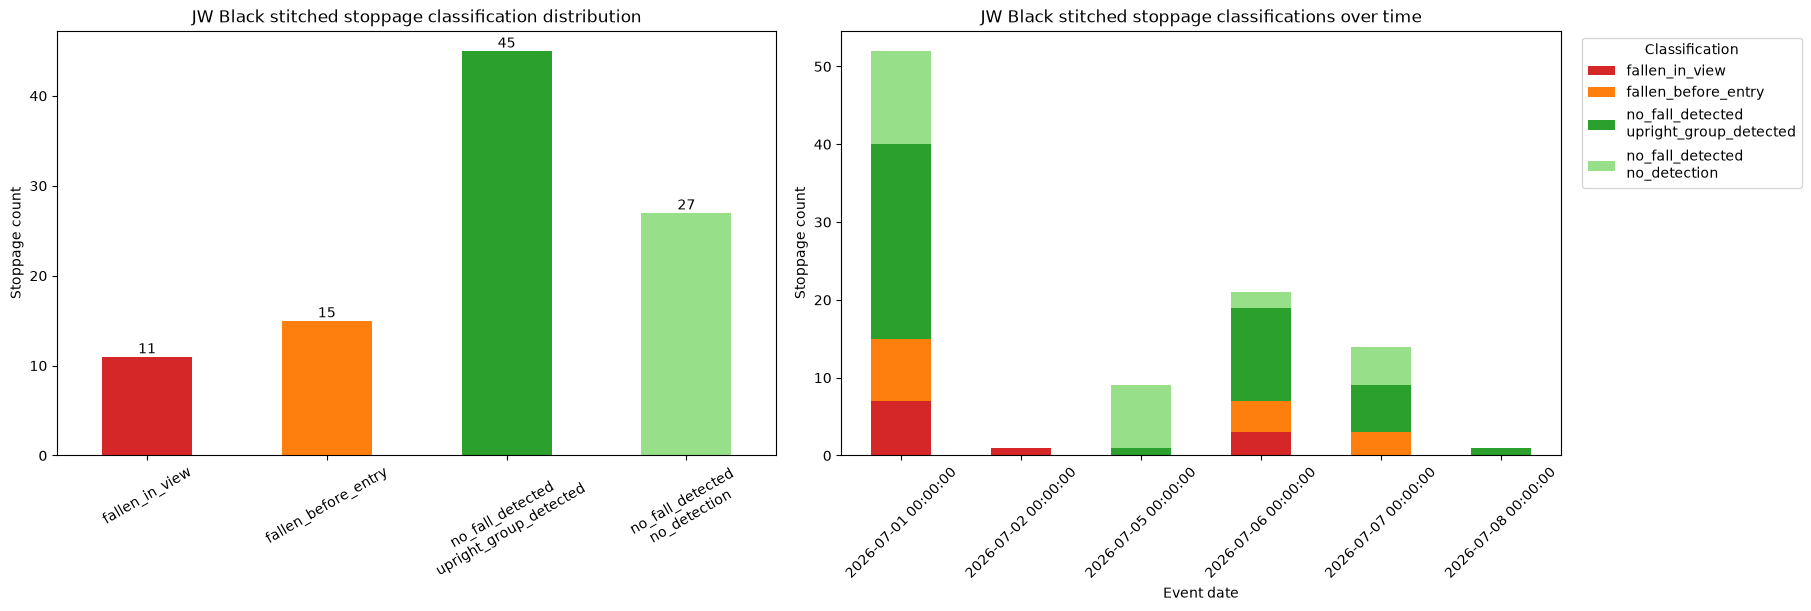

classification_detail,fallen_in_view,fallen_before_entry,no_fall_detected / upright_group_detected,no_fall_detected / no_detection
event_date,,,,
2026-07-01,7,8,25,12
2026-07-02,1,0,0,0
2026-07-05,0,0,1,8
2026-07-06,3,4,12,2
2026-07-07,0,3,6,5
2026-07-08,0,0,1,0


In [24]:
import matplotlib.pyplot as plt

chart_order = [
    "fallen_in_view",
    "fallen_before_entry",
    "no_fall_detected / upright_group_detected",
    "no_fall_detected / no_detection",
    "not_processed",
]
chart_colors = {
    "fallen_in_view": "#d62728",
    "fallen_before_entry": "#ff7f0e",
    "no_fall_detected / upright_group_detected": "#2ca02c",
    "no_fall_detected / no_detection": "#98df8a",
    "not_processed": "#c7c7c7",
}
chart_display_labels = {
    "no_fall_detected / upright_group_detected": "no_fall_detected\nupright_group_detected",
    "no_fall_detected / no_detection": "no_fall_detected\nno_detection",
}

distribution = (
    jw_black_stitched_stats["classification_detail"]
    .value_counts()
    .reindex(chart_order, fill_value=0)
)
distribution = distribution[distribution.gt(0)]

figure, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
distribution.plot(
    kind="bar",
    ax=axes[0],
    color=[chart_colors[label] for label in distribution.index],
)
axes[0].set_title("JW Black stitched stoppage classification distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Stoppage count")
axes[0].set_xticklabels([
    chart_display_labels.get(label, label) for label in distribution.index
])
axes[0].tick_params(axis="x", rotation=30)
for bar, count in zip(axes[0].patches, distribution.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, count, str(count), ha="center", va="bottom")

classification_over_time = jw_black_stitched_stats.copy()
classification_over_time["event_date"] = pd.to_datetime(
    classification_over_time["Event Time"], errors="coerce"
).dt.floor("D")
daily_distribution = (
    classification_over_time.dropna(subset=["event_date"])
    .groupby(["event_date", "classification_detail"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=chart_order, fill_value=0)
)
daily_distribution = daily_distribution.loc[:, daily_distribution.sum().gt(0)]
daily_distribution.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=[chart_colors[label] for label in daily_distribution.columns],
)
axes[1].set_title("JW Black stitched stoppage classifications over time")
axes[1].set_xlabel("Event date")
axes[1].set_ylabel("Stoppage count")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(
    labels=[chart_display_labels.get(label, label) for label in daily_distribution.columns],
    title="Classification", bbox_to_anchor=(1.02, 1), loc="upper left",
)

plt.show()
display(daily_distribution)

### All JW Black stoppages, including events with no footage

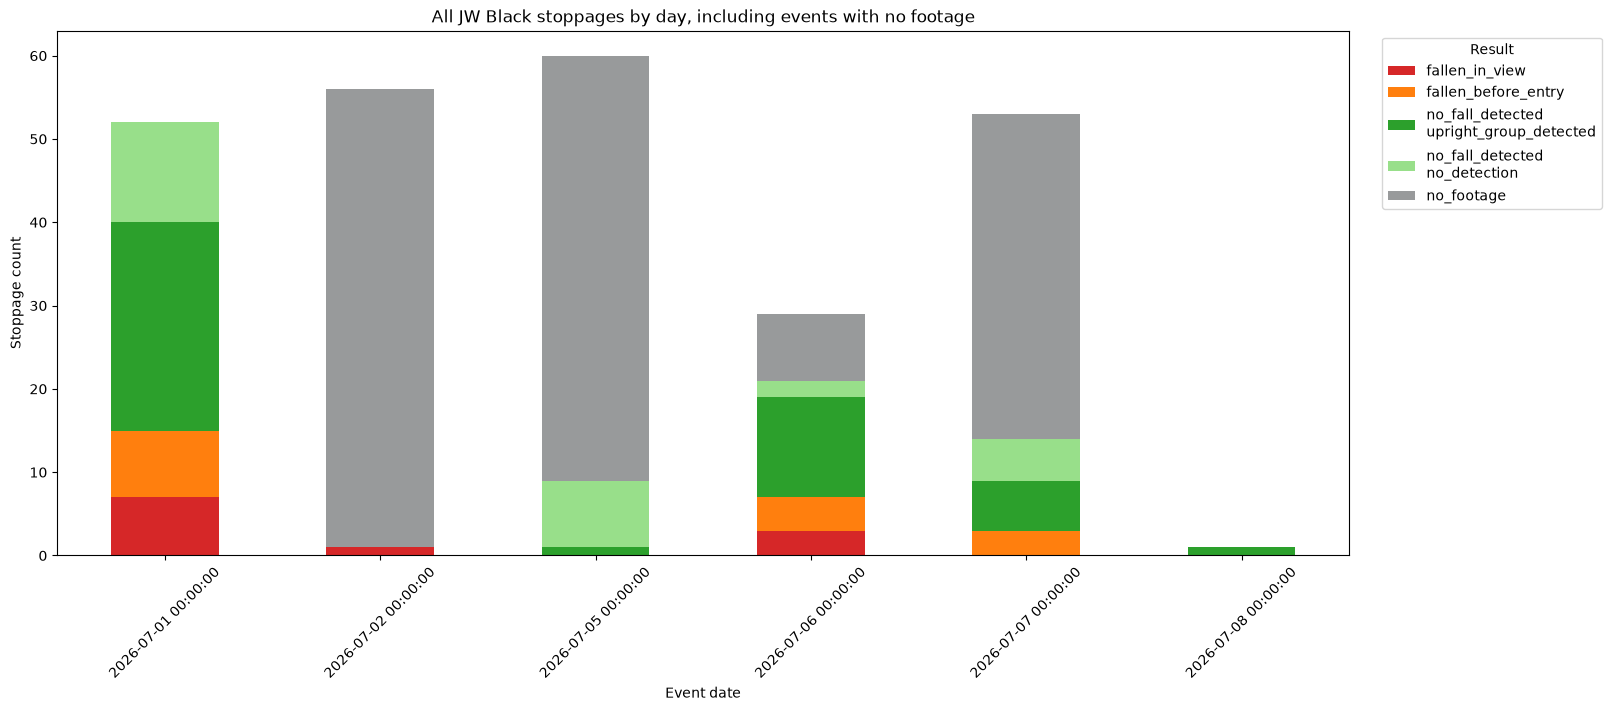

All JW Black stoppages: 251
With stitched footage:  98
Without footage:        153


,result,stoppage_count,percentage
0,fallen_in_view,11,4.4
1,fallen_before_entry,15,6.0
2,no_fall_detected / upright_group_detected,45,17.9
3,no_fall_detected / no_detection,27,10.8
5,no_footage,153,61.0


classification_detail,fallen_in_view,fallen_before_entry,no_fall_detected / upright_group_detected,no_fall_detected / no_detection,no_footage
event_date,,,,,
2026-07-01,7,8,25,12,0
2026-07-02,1,0,0,0,55
2026-07-05,0,0,1,8,51
2026-07-06,3,4,12,2,8
2026-07-07,0,3,6,5,39
2026-07-08,0,0,1,0,0


In [27]:
# Include every JW Black stoppage in the source event CSV.
all_stoppage_results = jw_black_events.merge(
    jw_black_stitched_stats[["event_id", "classification_detail"]],
    on="event_id",
    how="left",
)
all_stoppage_results["classification_detail"] = (
    all_stoppage_results["classification_detail"].fillna("no_footage")
)
all_stoppage_results["event_date"] = pd.to_datetime(
    all_stoppage_results["Event Time"], errors="coerce"
).dt.floor("D")

all_stoppage_order = [
    "fallen_in_view",
    "fallen_before_entry",
    "no_fall_detected / upright_group_detected",
    "no_fall_detected / no_detection",
    "not_processed",
    "no_footage",
]
all_stoppage_colors = {
    **chart_colors,
    "no_footage": "#989a9b",
}

all_stoppage_daily = (
    all_stoppage_results.dropna(subset=["event_date"])
    .groupby(["event_date", "classification_detail"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=all_stoppage_order, fill_value=0)
)
all_stoppage_daily = all_stoppage_daily.loc[:, all_stoppage_daily.sum().gt(0)]

figure, axis = plt.subplots(figsize=(16, 7), constrained_layout=True)
all_stoppage_daily.plot(
    kind="bar",
    stacked=True,
    ax=axis,
    color=[all_stoppage_colors[label] for label in all_stoppage_daily.columns],
)
axis.set_title("All JW Black stoppages by day, including events with no footage")
axis.set_xlabel("Event date")
axis.set_ylabel("Stoppage count")
axis.tick_params(axis="x", rotation=45)
axis.legend(
    labels=[chart_display_labels.get(label, label) for label in all_stoppage_daily.columns],
    title="Result", bbox_to_anchor=(1.02, 1), loc="upper left",
)
plt.show()

all_stoppage_summary = (
    all_stoppage_results["classification_detail"]
    .value_counts()
    .reindex(all_stoppage_order, fill_value=0)
    .rename("stoppage_count")
    .reset_index()
    .rename(columns={"classification_detail": "result"})
)
all_stoppage_summary = all_stoppage_summary[all_stoppage_summary["stoppage_count"].gt(0)]
all_stoppage_summary["percentage"] = (
    all_stoppage_summary["stoppage_count"]
    .div(len(all_stoppage_results))
    .mul(100)
    .round(1)
)

print(f"All JW Black stoppages: {len(all_stoppage_results):,}")
print(f"With stitched footage:  {(all_stoppage_results['classification_detail'] != 'no_footage').sum():,}")
print(f"Without footage:        {(all_stoppage_results['classification_detail'] == 'no_footage').sum():,}")
display(all_stoppage_summary)
display(all_stoppage_daily)